# 02 — Exploratory Data Analysis (EDA)

**Threat Incident Intelligence Platform**

This notebook explores the ingested ThreatCluster incident data stored in MongoDB.

Coverage:
- Score distributions (threat / severity / credibility)
- Urgency-level distribution
- Temporal trends (incidents over time)
- Keyword & entity frequency analysis
- Source / article count distributions
- High-threat incidents by sector, country, CVE, ATT&CK technique


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai


In [2]:
from collections import Counter
from datetime import datetime
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import settings, validate_config
from src.db import (
    ping_database,
    close_connection,
    count_incidents,
    find_incidents,
    get_urgency_distribution,
    get_score_statistics,
    get_entity_values,
    get_recent_incidents,
)
from src.utils import setup_logging, timer, truncate_text, format_score

logger = setup_logging("INFO", name="eda")
validate_config()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print("Setup complete")

[config] MongoDB URI loaded (db=threat_intelligence)
[config] Collections: ['incidents', 'incident_features', 'predictions', 'models_metadata']
Setup complete


In [3]:
if not ping_database():
    raise RuntimeError("Cannot reach MongoDB. Check .env and ensure the server is running.")

total = count_incidents()
print(f"Total incidents in MongoDB: {total:,}")
if total == 0:
    raise RuntimeError("No documents found. Run 01_data_ingestion.ipynb first.")

Total incidents in MongoDB: 19,204


In [4]:
with timer("Loading all incidents from MongoDB"):
    docs = find_incidents(
        projection={
            "_id": 0,
            "cluster_id": 1,
            "title": 1,
            "summary": 1,
            "entities": 1,
            "keywords": 1,
            "sources": 1,
            "source_count": 1,
            "article_count": 1,
            "threat_score": 1,
            "severity_score": 1,
            "credibility_score": 1,
            "urgency_level": 1,
            "first_reported": 1,
            "last_reported": 1,
            "url": 1,
        }
    )

df = pd.DataFrame(docs)
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

[timer] Loading all incidents from MongoDB: 0.70s
DataFrame shape: (19204, 15)
Columns: ['cluster_id', 'title', 'summary', 'entities', 'keywords', 'sources', 'source_count', 'article_count', 'threat_score', 'severity_score', 'credibility_score', 'urgency_level', 'first_reported', 'last_reported', 'url']


,cluster_id,title,summary,entities,keywords,sources,source_count,article_count,threat_score,severity_score,credibility_score,urgency_level,first_reported,last_reported,url
0,971184ec,MikroTik RouterOS Vulnerabilities Under Active...,CERT Polska has identified six critical vulner...,"{'cve': ['CVE-2026-67276', 'CVE-2026-67277', '...","[mikrotik, routeros, vulnerability, vulnerabil...","[Cert.Pl, mikrotik.com]",2,2,78.65,85.0,0.0,medium,2026-09-06,2026-09-06,https://threatcluster.io/cluster/971184ec
1,ec7534a8,Cyber Security Roles Address NHS Threats Amid ...,Two cybersecurity roles have been announced to...,"{'company': ['NHS'], 'country': ['United Kingd...","[security, cyber, analyst, remote, consultant,...","[Glosjobs, Outsideir35.Uk]",2,2,39.00,40.0,0.0,medium,2026-09-06,2026-09-06,https://threatcluster.io/cluster/ec7534a8
2,95d7c722,JetBrains Cadence Breach: Exploitation of Unpa...,"Between August 8 and August 24, 2026, attacker...","{'cve': ['CVE-2026-63077'], 'cwe': ['CWE-200 -...","[jetbrains, teamcity, critical, cadence, attac...","[Rescana, Thehackernews, thenewstack.io, www.r...",4,4,72.75,81.0,0.0,medium,2026-09-05,2026-09-06,https://threatcluster.io/cluster/95d7c722


In [5]:
print("=== Dataset Overview ===")
print(f"Records          : {len(df):,}")
print(f"Unique cluster_id: {df['cluster_id'].nunique():,}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False) if missing.any() else "  (none)")
print(f"\nDtypes:")
print(df.dtypes)

=== Dataset Overview ===
Records          : 19,204
Unique cluster_id: 19,204

Missing values:
  (none)

Dtypes:
cluster_id                   object
title                        object
summary                      object
entities                     object
keywords                     object
sources                      object
source_count                  int64
article_count                 int64
threat_score                float64
severity_score              float64
credibility_score           float64
urgency_level                object
first_reported       datetime64[ns]
last_reported        datetime64[ns]
url                          object
dtype: object


In [6]:
numeric_cols = ["threat_score", "severity_score", "credibility_score",
                "source_count", "article_count"]
numeric_cols = [c for c in numeric_cols if c in df.columns]
df[numeric_cols].describe().round(2)

,threat_score,severity_score,credibility_score,source_count,article_count
count,19204.00,19204.00,19204.00,19204.00,19204.00
mean,45.43,41.99,0.28,4.67,6.84
std,18.63,28.55,3.72,18.11,51.71
min,10.00,0.00,0.00,1.00,2.00
25%,27.90,19.00,0.00,2.00,2.00
50%,43.91,41.00,0.00,2.00,2.00
75%,61.50,61.44,0.00,4.00,4.00
max,96.90,100.00,50.00,1504.00,4448.00


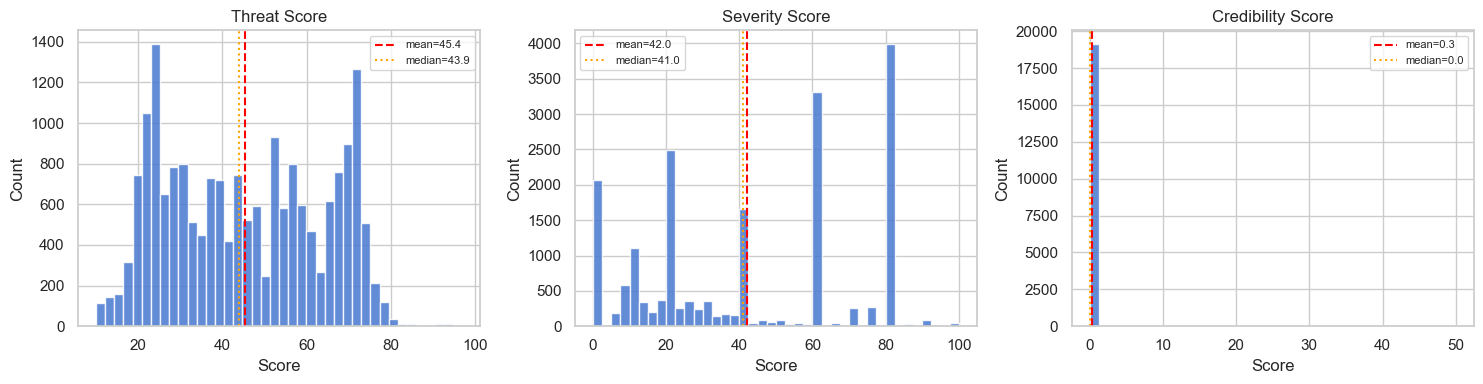

threat_score: {'count': 19204, 'avg': 45.4303, 'min': 10.0, 'max': 96.9, 'std': 18.6304}
severity_score: {'count': 19204, 'avg': 41.9861, 'min': 0.0, 'max': 100.0, 'std': 28.5485}
credibility_score: {'count': 19204, 'avg': 0.2786, 'min': 0.0, 'max': 50.0, 'std': 3.7218}


In [7]:
score_fields = ["threat_score", "severity_score", "credibility_score"]
score_fields = [c for c in score_fields if c in df.columns]

fig, axes = plt.subplots(1, len(score_fields), figsize=(5 * len(score_fields), 4))
if len(score_fields) == 1:
    axes = [axes]

for ax, col in zip(axes, score_fields):
    data = df[col].dropna()
    ax.hist(data, bins=40, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color="orange", linestyle=":", label=f"median={data.median():.1f}")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for col in score_fields:
    stats = get_score_statistics(col)
    print(f"{col}: {stats}")

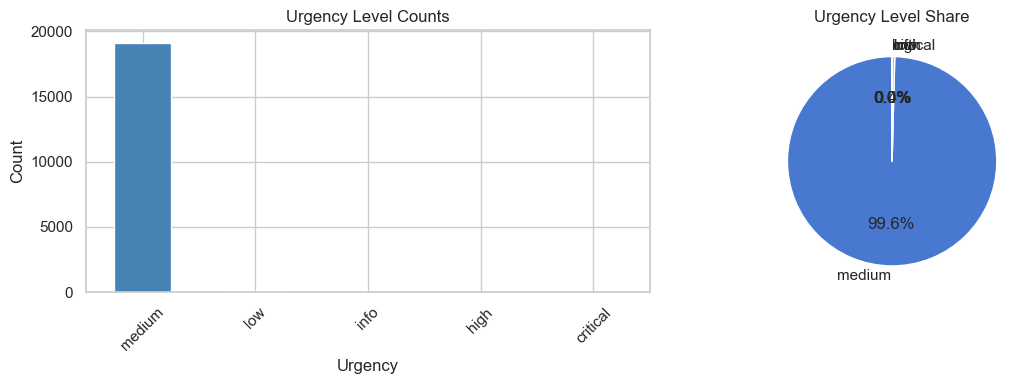

medium      19127
low            68
info            4
high            3
critical        2


In [8]:
urgency_dist = get_urgency_distribution()
urgency_series = pd.Series(urgency_dist).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

urgency_series.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Urgency Level Counts")
axes[0].set_xlabel("Urgency")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(
    urgency_series.values,
    labels=urgency_series.index,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Urgency Level Share")

plt.tight_layout()
plt.show()

print(urgency_series.to_string())

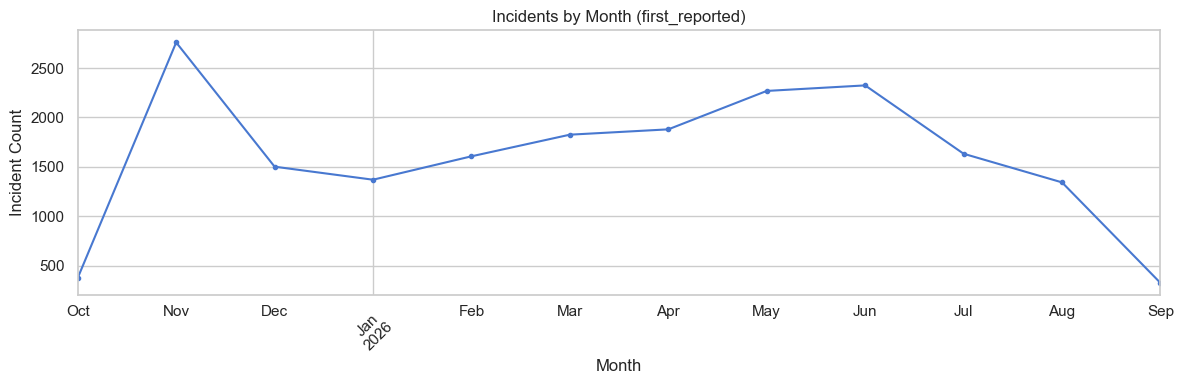

Date range: 2025-10-22 00:00:00 → 2026-09-06 00:00:00
Months covered: 12


In [9]:
for col in ["first_reported", "last_reported"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "first_reported" in df.columns and df["first_reported"].notna().any():
    df["report_month"] = df["first_reported"].dt.to_period("M")
    monthly = df.groupby("report_month").size()

    fig, ax = plt.subplots(figsize=(12, 4))
    monthly.plot(ax=ax, marker="o", markersize=3)
    ax.set_title("Incidents by Month (first_reported)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Incident Count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"Date range: {df['first_reported'].min()} → {df['first_reported'].max()}")
    print(f"Months covered: {monthly.shape[0]}")
else:
    print("No usable first_reported dates found.")

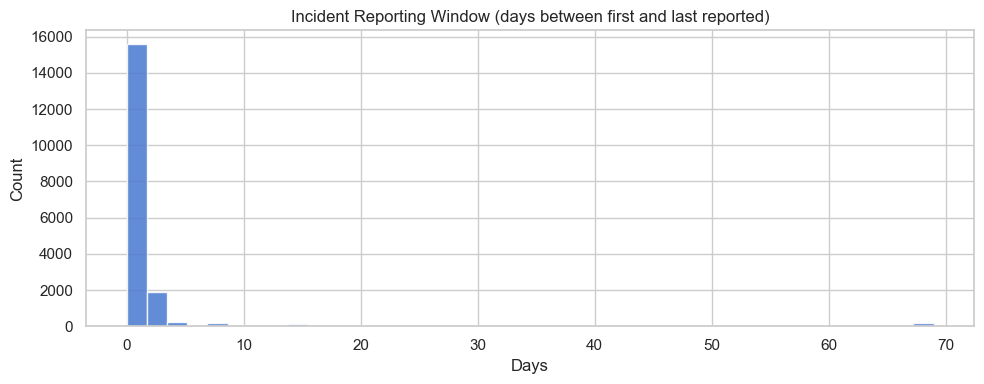

Median duration : 0 days
Mean duration   : 3.0 days
Max duration    : 111 days


In [10]:
if "first_reported" in df.columns and "last_reported" in df.columns:
    mask = df["first_reported"].notna() & df["last_reported"].notna()
    duration_days = (df.loc[mask, "last_reported"] - df.loc[mask, "first_reported"]).dt.days
    duration_days = duration_days[duration_days >= 0]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(duration_days.clip(upper=duration_days.quantile(0.99)), bins=40,
            edgecolor="white", alpha=0.85)
    ax.set_title("Incident Reporting Window (days between first and last reported)")
    ax.set_xlabel("Days")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    print(f"Median duration : {duration_days.median():.0f} days")
    print(f"Mean duration   : {duration_days.mean():.1f} days")
    print(f"Max duration    : {duration_days.max():.0f} days")

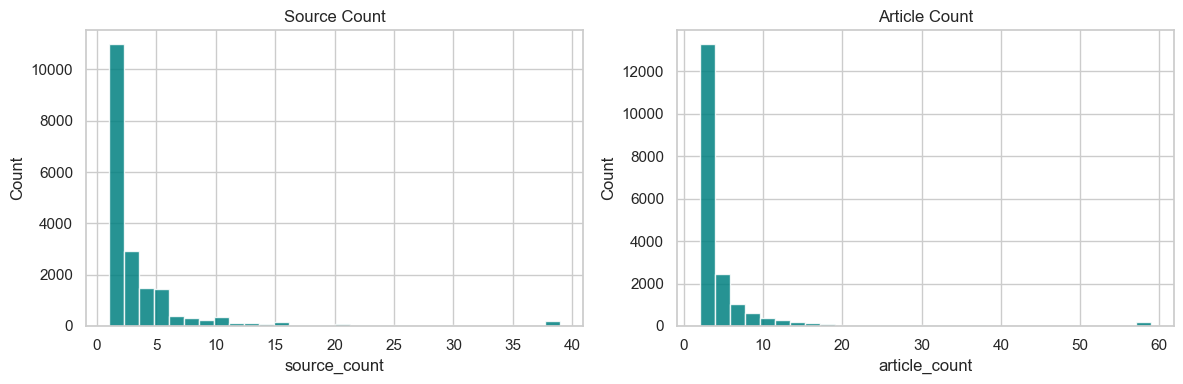

source_count: mean=4.67, median=2, max=1504
article_count: mean=6.84, median=2, max=4448


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["source_count", "article_count"]):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    data = df[col].dropna().clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=30, edgecolor="white", alpha=0.85, color="teal")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

for col in ["source_count", "article_count"]:
    if col in df.columns:
        print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.0f}, max={df[col].max()}")

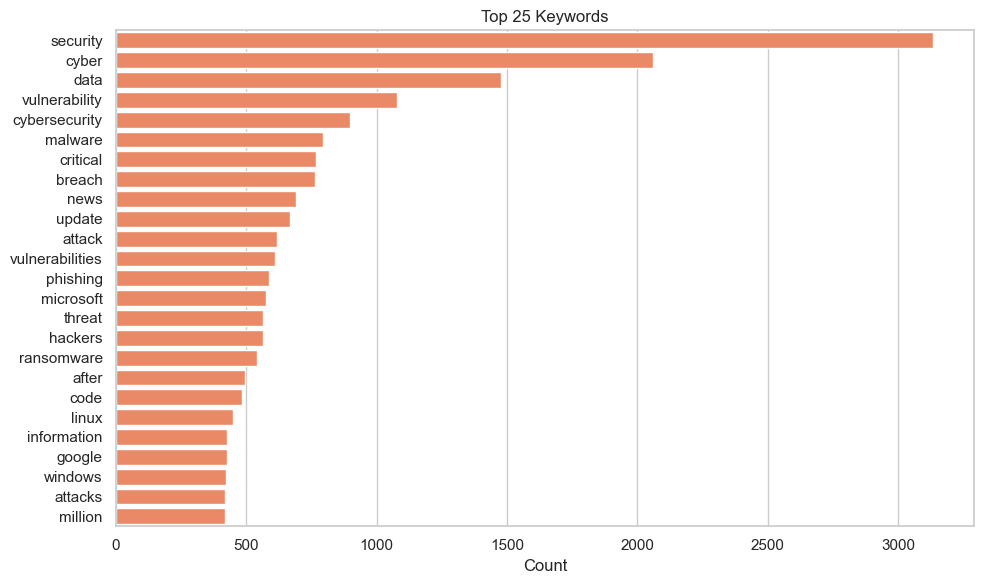

Unique keywords: 19,399
      keyword  count
     security   3135
        cyber   2061
         data   1477
vulnerability   1077
cybersecurity    897
      malware    793
     critical    767
       breach    764
         news    690
       update    668


In [12]:
keyword_counter = Counter()
for kws in df["keywords"].dropna():
    if isinstance(kws, list):
        keyword_counter.update([str(k).lower().strip() for k in kws if k])

top_keywords = keyword_counter.most_common(25)
kw_df = pd.DataFrame(top_keywords, columns=["keyword", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=kw_df, y="keyword", x="count", ax=ax, color="coral")
ax.set_title("Top 25 Keywords")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Unique keywords: {len(keyword_counter):,}")
print(kw_df.head(10).to_string(index=False))

In [13]:
ENTITY_TYPES = ["cve", "company", "malware", "country", "sector", "mitre_attack"]

entity_summaries = {}
for etype in ENTITY_TYPES:
    values = get_entity_values(etype, limit=15)
    entity_summaries[etype] = values
    print(f"\n=== Top {etype} ===")
    if not values:
        print("  (no data)")
        continue
    for item in values[:10]:
        print(f"  {item['value'][:60]:60s}  {item['count']:,}")


=== Top cve ===
  CVE-2025-55182                                                36
  CVE-2026-3644                                                 25
  CVE-2025-61882                                                25
  CVE-2026-6019                                                 25
  CVE-2026-7261                                                 24
  CVE-2026-6722                                                 24
  CVE-2026-33846                                                23
  CVE-2026-56123                                                23
  CVE-2026-42009                                                23
  CVE-2026-41991                                                23

=== Top company ===
  Microsoft                                                     189
  Google                                                        109
  Jaguar Land Rover                                             84
  Anthropic                                                     75
  OpenAI              

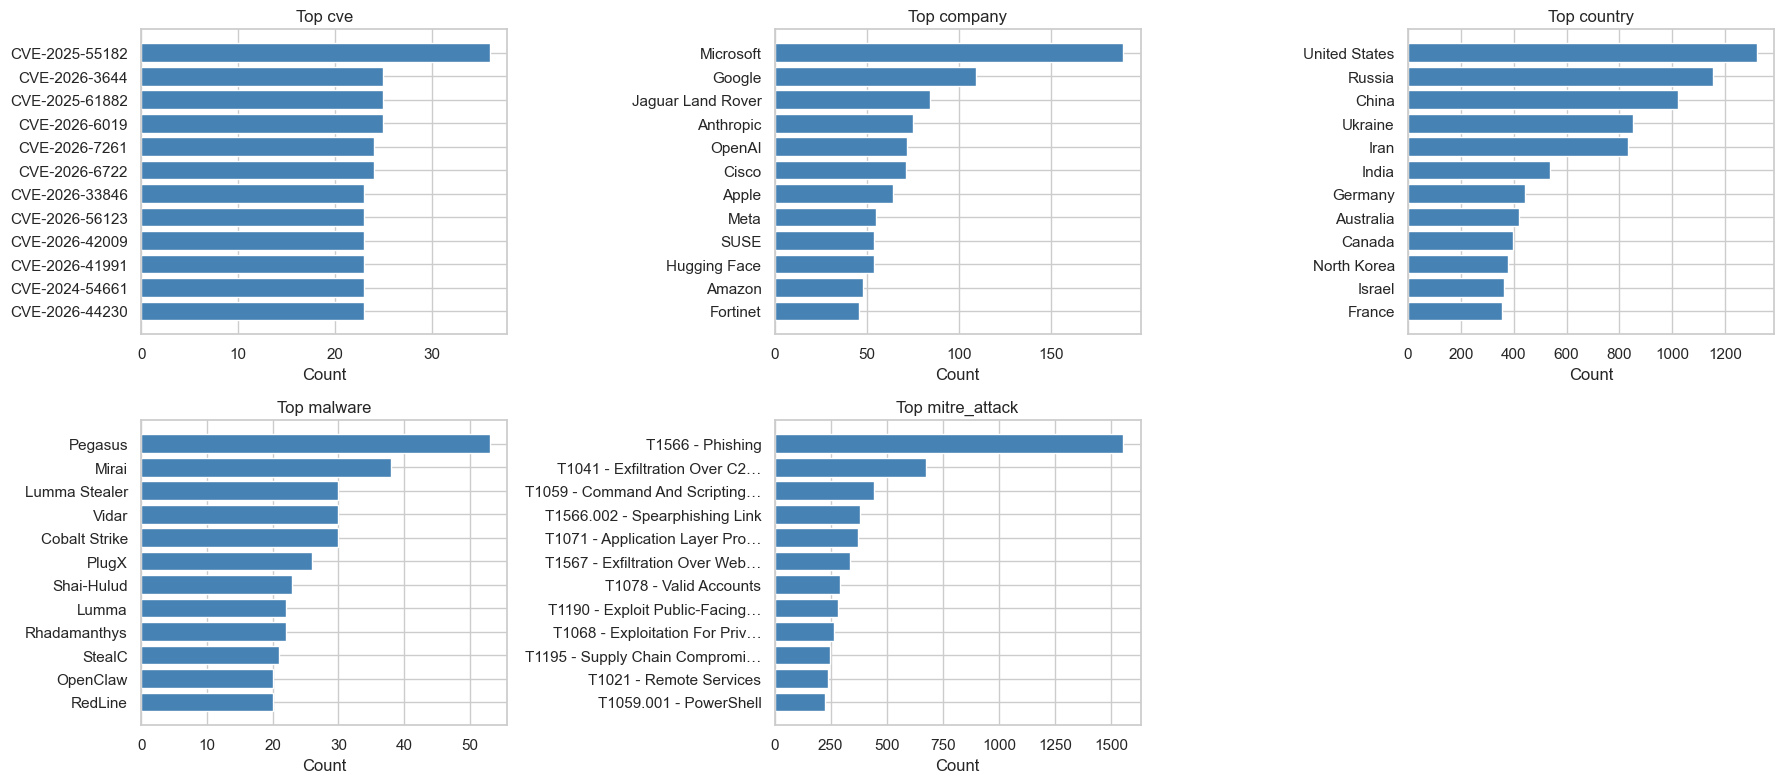

In [14]:
plot_types = [t for t in ["cve", "company", "country", "sector", "malware", "mitre_attack"]
              if entity_summaries.get(t)]

n = len(plot_types)
if n == 0:
    print("No entity data to plot.")
else:
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, etype in zip(axes, plot_types):
        items = entity_summaries[etype][:12]
        labels = [truncate_text(i["value"], 30) for i in items]
        counts = [i["count"] for i in items]
        ax.barh(labels[::-1], counts[::-1], color="steelblue")
        ax.set_title(f"Top {etype}")
        ax.set_xlabel("Count")

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [15]:
if "threat_score" in df.columns:
    threshold = df["threat_score"].quantile(0.90)
    high = df[df["threat_score"] >= threshold].copy()
    print(f"High-threat threshold (90th pctile): {threshold:.1f}")
    print(f"High-threat incidents: {len(high):,}")

    display_cols = [c for c in ["cluster_id", "title", "threat_score",
                                 "severity_score", "urgency_level",
                                 "source_count", "article_count"] if c in high.columns]
    top_high = high.nlargest(15, "threat_score")[display_cols]
    top_high["title"] = top_high["title"].apply(lambda t: truncate_text(str(t), 60))
    print("\nTop 15 by threat_score:")
    display(top_high.reset_index(drop=True))
else:
    print("threat_score column not available.")

High-threat threshold (90th pctile): 71.8
High-threat incidents: 1,944

Top 15 by threat_score:


,cluster_id,title,threat_score,severity_score,urgency_level,source_count,article_count
0,6a0b6977,Google Addresses Eighth Chrome Zero-Day Vulner...,96.90,100.0,medium,33,45
1,2a013eaf,Apple Fixes Zero-Day Vulnerability in Software...,96.31,100.0,medium,4,5
2,0867d1d8,UAT-7290 Cyber Espionage Targets South Asian T...,95.82,100.0,medium,2,2
3,3db972ca,Cisco Fixes Critical AsyncOS Vulnerability Und...,95.80,100.0,medium,9,11
4,8c5c4c5c,CISA Directs Agencies to Address Gogs RCE Vuln...,95.18,100.0,medium,5,6
5,ab04c1ec,Cisco Addresses AsyncOS Zero-Day Exploited by ...,94.96,100.0,medium,3,3
6,c2f70097,APT28 Exploits MSHTML Zero-Day Vulnerability i...,94.31,100.0,medium,4,4
7,ceef6b1e,Microsoft Office 0-day Vulnerability CVE-2026-...,94.31,100.0,medium,6,7
8,5e7700b1,Critical 0-Day RCE Flaw in Networking Devices ...,94.31,100.0,medium,3,4
9,8b442c8e,Critical Zero-Day Vulnerability CVE-2025-14733...,94.31,100.0,medium,4,4


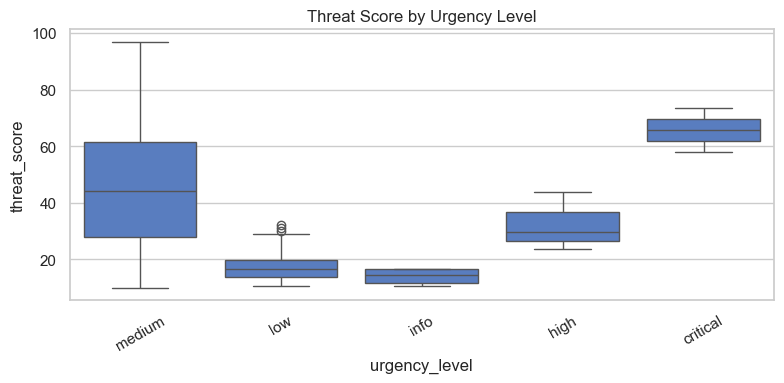

In [16]:
if "threat_score" in df.columns and "urgency_level" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df, x="urgency_level", y="threat_score", ax=ax)
    ax.set_title("Threat Score by Urgency Level")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

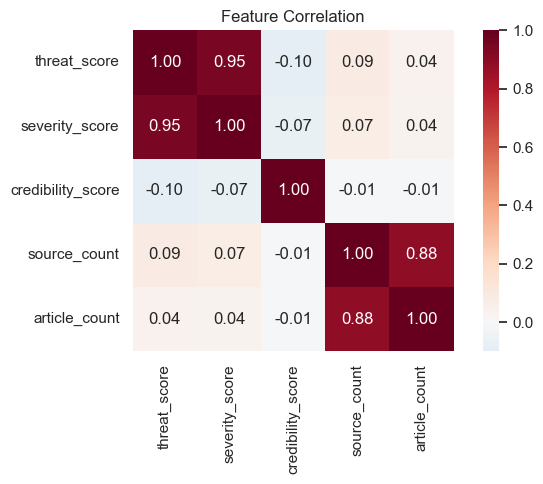

In [17]:
corr_cols = [c for c in ["threat_score", "severity_score", "credibility_score",
                          "source_count", "article_count"] if c in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, ax=ax)
    ax.set_title("Feature Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation.")

In [20]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Total incidents       : {len(df):,}")
print(f"Date range            : {df['first_reported'].min() if 'first_reported' in df.columns else 'N/A'}"
      f" → {df['first_reported'].max() if 'first_reported' in df.columns else 'N/A'}")
print(f"Urgency levels        : {dict(urgency_dist)}")
if "threat_score" in df.columns:
    print(f"Threat score mean/med : {df['threat_score'].mean():.1f} / {df['threat_score'].median():.1f}")
print(f"Unique keywords       : {len(keyword_counter):,}")
for etype in ENTITY_TYPES:
    n = len(entity_summaries.get(etype, []))
    print(f"Top-{min(n,15)} {etype:15s}: shown above")

EDA SUMMARY
Total incidents       : 19,204
Date range            : 2025-10-22 00:00:00 → 2026-09-06 00:00:00
Urgency levels        : {'medium': 19127, 'low': 68, 'info': 4, 'high': 3, 'critical': 2}
Threat score mean/med : 45.4 / 43.9
Unique keywords       : 19,399
Top-15 cve            : shown above
Top-15 company        : shown above
Top-15 malware        : shown above
Top-15 country        : shown above
Top-0 sector         : shown above
Top-15 mitre_attack   : shown above


In [21]:
close_connection()
print("MongoDB connection closed.")

MongoDB connection closed.
